In [ ]:
!pip install torch torchvision matplotlib pillow

In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchvision import models
import torch.nn.functional as F

# Mount Google Drive if not mounted
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

data_dir = '/content/drive/MyDrive/ML_Safety'
models_dir = os.path.join(data_dir, 'models')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Mounted at /content/drive
Using device: cuda


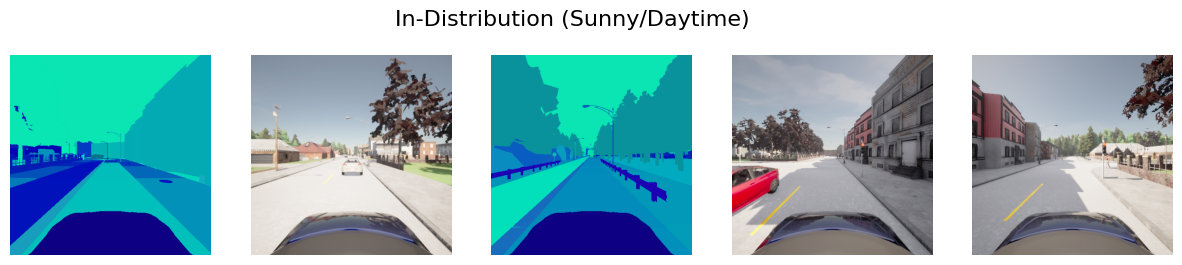

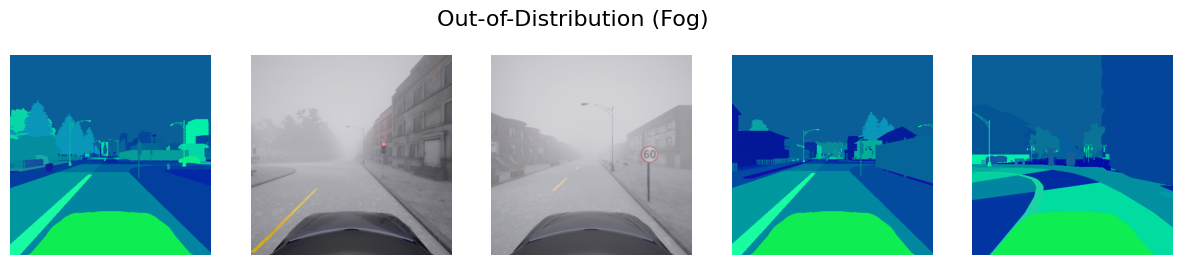

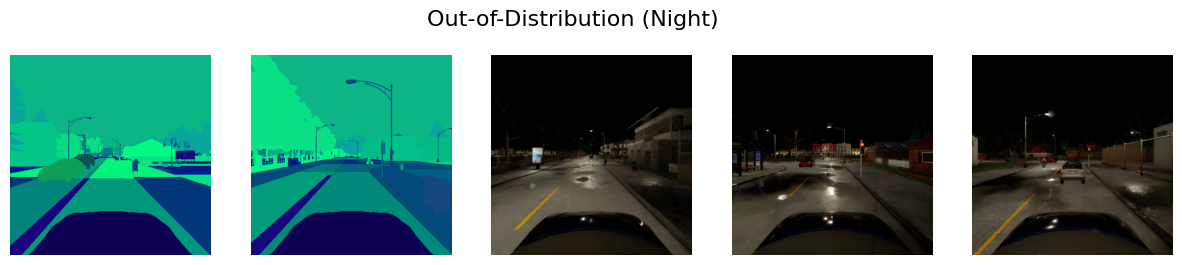

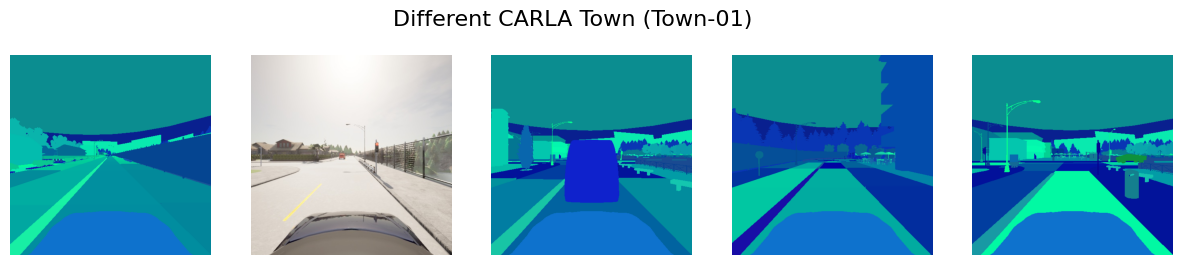

In [2]:
def get_random_images(directory, num_images=5):
    all_images = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith(('.png', '.jpg', '.jpeg')):
                all_images.append(os.path.join(root, file))
    if not all_images:
        return []
    return random.sample(all_images, min(num_images, len(all_images)))

def show_images_in_row(image_paths, title):
    if not image_paths:
        print(f"No images found for {title}")
        return
    fig, axes = plt.subplots(1, len(image_paths), figsize=(15, 3))
    if len(image_paths) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=16)
    for ax, img_path in zip(axes, image_paths):
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
    plt.show()

# Display five in-distribution, fog, and night images
train_imgs = get_random_images(os.path.join(data_dir, 'train'))
fog_imgs = get_random_images(os.path.join(data_dir, 'test-fog'))
night_imgs = get_random_images(os.path.join(data_dir, 'test-night'))

show_images_in_row(train_imgs, 'In-Distribution (Sunny/Daytime)')
show_images_in_row(fog_imgs, 'Out-of-Distribution (Fog)')
show_images_in_row(night_imgs, 'Out-of-Distribution (Night)')

# Display five images from different CARLA town
town_imgs = get_random_images(os.path.join(data_dir, 'test-town-01'))
show_images_in_row(town_imgs, 'Different CARLA Town (Town-01)')

In [ ]:
def load_model(model_path):
    # Note: weights parameter replaces pretrained in newer torchvision versions
    model = models.resnet18(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = torch.nn.Linear(num_ftrs, 1)  # Binary classification with 1 output
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
    except FileNotFoundError:
        print(f"Warning: Model file not found at {model_path}")
        return None
    model.to(device)
    model.eval()
    return model

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def compute_mean_confidence(model, directory, num_samples=100):
    if model is None:
        return 0.0
    images = get_random_images(directory, num_samples)
    if not images:
        return 0.0

    confidences = []
    with torch.no_grad():
        for img_path in images:
            try:
                img = Image.open(img_path).convert('RGB')
                img_t = transform(img).unsqueeze(0).to(device)
                outputs = model(img_t)
                prob = torch.sigmoid(outputs).item()
                # Confidence is the max probability between the two classes (prob and 1-prob)
                max_prob = max(prob, 1.0 - prob)
                confidences.append(max_prob)
            except Exception as e:
                pass

    if not confidences:
        return 0.0
    return sum(confidences) / len(confidences)

# Load models
models_dict = {
    'Pedestrian': load_model(os.path.join(models_dir, 'pedestrian_resnet18.pth')),
    'Traffic Light': load_model(os.path.join(models_dir, 'traffic_light_resnet18.pth')),
    'Vehicle': load_model(os.path.join(models_dir, 'vehicle_resnet18.pth'))
}

# Directories to evaluate
eval_dirs = {
    'In-Distribution (Train)': os.path.join(data_dir, 'train'),
    'Fog (OOD)': os.path.join(data_dir, 'test-fog'),
    'Night (OOD)': os.path.join(data_dir, 'test-night')
}

print("Mean Softmax Confidence:")
print("-" * 50)
for model_name, model in models_dict.items():
    print(f"Model: {model_name}")
    for dir_name, dir_path in eval_dirs.items():
        mean_conf = compute_mean_confidence(model, dir_path)
        print(f"  {dir_name}: {mean_conf:.4f}")
    print("-" * 50)

Mean Softmax Confidence:
--------------------------------------------------
Model: Pedestrian
  In-Distribution (Train): 0.9317
  Fog (OOD): 0.9234
  Night (OOD): 0.9224
--------------------------------------------------
Model: Traffic Light
  In-Distribution (Train): 0.9883
  Fog (OOD): 0.9315
  Night (OOD): 0.9590
--------------------------------------------------
Model: Vehicle
  In-Distribution (Train): 0.9676
  Fog (OOD): 0.9189
  Night (OOD): 0.8704
--------------------------------------------------


In [ ]:
print("hi")

hi


Evaluating MSP Baseline using the Vehicle model...
Extracting confidence scores for In-Distribution (Sunny/Daytime Test)...
Extracting confidence scores for OOD (Fog and Night)...


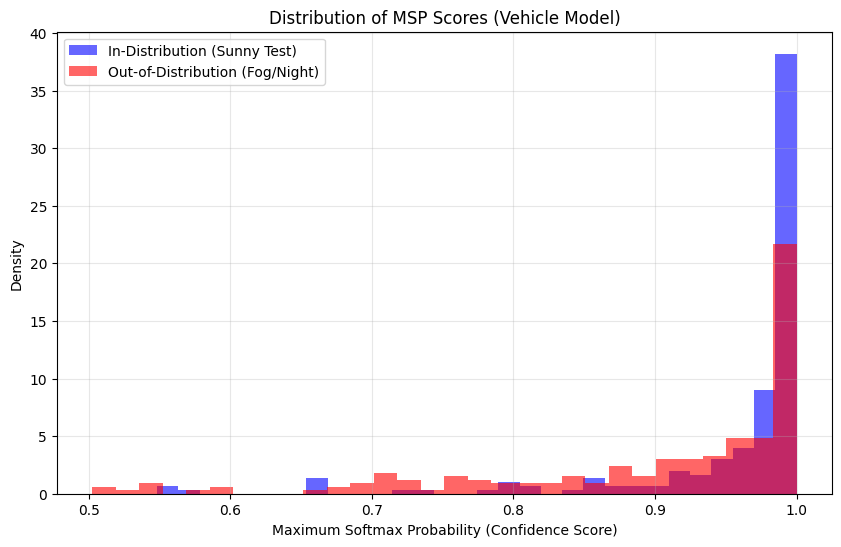

AUROC for separating In-Distribution from OOD using MSP: 0.6875


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

def get_all_confidences(model, directory, num_samples=150):
    images = get_random_images(directory, num_samples)
    if not images:
        return []

    confidences = []
    with torch.no_grad():
        for img_path in images:
            try:
                img = Image.open(img_path).convert('RGB')
                img_t = transform(img).unsqueeze(0).to(device)
                outputs = model(img_t)
                prob = torch.sigmoid(outputs).item()
                max_prob = max(prob, 1.0 - prob)
                confidences.append(max_prob)
            except Exception as e:
                pass
    return confidences

# Pick one model (e.g., Vehicle model)
selected_model_name = 'Vehicle'
selected_model = models_dict[selected_model_name]
print(f"Evaluating MSP Baseline using the {selected_model_name} model...")

print("Extracting confidence scores for In-Distribution (Sunny/Daytime Test)...")
id_dir = os.path.join(data_dir, 'test')
id_confidences = get_all_confidences(selected_model, id_dir, num_samples=200)

print("Extracting confidence scores for OOD (Fog and Night)...")
fog_confidences = get_all_confidences(selected_model, os.path.join(data_dir, 'test-fog'), num_samples=100)
night_confidences = get_all_confidences(selected_model, os.path.join(data_dir, 'test-night'), num_samples=100)
ood_confidences = fog_confidences + night_confidences

# 1. Plot the distribution of OOD scores (MSP)
plt.figure(figsize=(10, 6))
plt.hist(id_confidences, bins=30, alpha=0.6, label='In-Distribution (Sunny Test)', color='blue', density=True)
plt.hist(ood_confidences, bins=30, alpha=0.6, label='Out-of-Distribution (Fog/Night)', color='red', density=True)
plt.xlabel('Maximum Softmax Probability (Confidence Score)')
plt.ylabel('Density')
plt.title(f'Distribution of MSP Scores ({selected_model_name} Model)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Compute AUROC
# Treat ID as positive class (1) and OOD as negative class (0) since ID typically has higher confidence
if len(id_confidences) > 0 and len(ood_confidences) > 0:
    y_true = np.concatenate([np.ones(len(id_confidences)), np.zeros(len(ood_confidences))])
    y_scores = np.concatenate([id_confidences, ood_confidences])

    auroc = roc_auc_score(y_true, y_scores)
    print(f"AUROC for separating In-Distribution from OOD using MSP: {auroc:.4f}")
else:
    print("Could not compute AUROC: Missing confidence scores for ID or OOD data.")


In [ ]:
from sklearn.neighbors import NearestNeighbors

print(f"Evaluating Feature-Based (k-NN) OOD Detection using the {selected_model_name} model...")

# 1. Create a feature extractor (remove the final fully connected layer)
feature_extractor = torch.nn.Sequential(*(list(selected_model.children())[:-1]))
feature_extractor.to(device)
feature_extractor.eval()

def extract_features(directory, num_samples=200):
    images = get_random_images(directory, num_samples)
    if not images:
        return np.array([])

    features = []
    with torch.no_grad():
        for img_path in images:
            try:
                img = Image.open(img_path).convert('RGB')
                img_t = transform(img).unsqueeze(0).to(device)

                # Extract features (outputs shape [1, 512, 1, 1] for ResNet18)
                feat = feature_extractor(img_t)

                # Flatten to 1D array of size 512
                feat = feat.view(feat.size(0), -1).cpu().numpy().flatten()
                features.append(feat)
            except Exception as e:
                pass
    return np.array(features)

print("Extracting ID training features for fitting k-NN...")
train_dir = os.path.join(data_dir, 'train')
train_features = extract_features(train_dir, num_samples=300)

print("Extracting test ID and OOD features...")
test_id_features = extract_features(os.path.join(data_dir, 'test'), num_samples=150)
test_fog_features = extract_features(os.path.join(data_dir, 'test-fog'), num_samples=150)
test_night_features = extract_features(os.path.join(data_dir, 'test-night'), num_samples=150)

# 2. Fit the detector (k-NN) on ID features
print("Fitting k-NN detector (k=5)...")
knn = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn.fit(train_features)

# Score test images: The OOD score is the distance to the k-nearest neighbors.
# Larger distance -> more OOD.
def score_features(features):
    if len(features) == 0:
        return []
    distances, _ = knn.kneighbors(features)
    return distances.mean(axis=1) # average distance to the 5 nearest neighbors

knn_id_scores = score_features(test_id_features)
knn_fog_scores = score_features(test_fog_features)
knn_night_scores = score_features(test_night_features)

# 3. Compute AUROC and compare to MSP AUROC
# Note for k-NN: Larger distance = Positive class (OOD) (label 1)
#                Smaller distance = Negative class (ID) (label 0)
def get_auroc(id_scores, ood_scores):
    if len(id_scores) == 0 or len(ood_scores) == 0: return 0.0
    y_true = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    y_scores = np.concatenate([id_scores, ood_scores])
    return roc_auc_score(y_true, y_scores)

auroc_knn_fog = get_auroc(knn_id_scores, knn_fog_scores)
auroc_knn_night = get_auroc(knn_id_scores, knn_night_scores)

print(f"\n--- Feature-Based (k-NN) AUROC Results ---")
print(f"AUROC (Sunny vs Fog):   {auroc_knn_fog:.4f}")
print(f"AUROC (Sunny vs Night): {auroc_knn_night:.4f}")

# Re-calculate individual MSP AUROCs for exact comparison
if len(id_confidences) > 0 and len(fog_confidences) > 0 and len(night_confidences) > 0:
    # Note for MSP: Larger confidence = Positive class (ID) (label 1)
    # We invert logic from before just to be consistent, but sklearn handles it if we match labels:
    y_true_msp_fog = np.concatenate([np.ones(len(id_confidences)), np.zeros(len(fog_confidences))])
    y_scores_msp_fog = np.concatenate([id_confidences, fog_confidences])
    msp_auroc_fog = roc_auc_score(y_true_msp_fog, y_scores_msp_fog)

    y_true_msp_night = np.concatenate([np.ones(len(id_confidences)), np.zeros(len(night_confidences))])
    y_scores_msp_night = np.concatenate([id_confidences, night_confidences])
    msp_auroc_night = roc_auc_score(y_true_msp_night, y_scores_msp_night)

    print(f"\n--- Baseline MSP AUROC Results (from Ex 9.6) ---")
    print(f"AUROC (Sunny vs Fog):   {msp_auroc_fog:.4f} (Gap: {auroc_knn_fog - msp_auroc_fog:+.4f})")
    print(f"AUROC (Sunny vs Night): {msp_auroc_night:.4f} (Gap: {auroc_knn_night - msp_auroc_night:+.4f})")


Evaluating Feature-Based (k-NN) OOD Detection using the Vehicle model...
Extracting ID training features for fitting k-NN...
Extracting test ID and OOD features...
Fitting k-NN detector (k=5)...

--- Feature-Based (k-NN) AUROC Results ---
AUROC (Sunny vs Fog):   0.7139
AUROC (Sunny vs Night): 0.6534

--- Baseline MSP AUROC Results (from Ex 9.6) ---
AUROC (Sunny vs Fog):   0.6817 (Gap: +0.0322)
AUROC (Sunny vs Night): 0.6932 (Gap: -0.0398)


In [ ]:
print("hi")

hi
